# 프로젝트 1. 택시 이용내역 데이터 (데이터 전처리와 시각화)
## 목표: 다양한 Data cleaning 기술을 활용하여 cleaning된 나만의 데이터를 만들고 정리한다.


Step 1. 이것만큼은 꼭 해보세요!

결측치 판단 및 처리
[힌트] 결측치의 유무와 비율을 살펴보고 적절한 방법으로 처리합니다.
이상치 판단 및 처리
[힌트] 숫자형 변수 각각에 대해, 데이터의 index와 변수 값 사이의 scatter plot을 그려보고 이상치가 관찰될 경우 제거합니다.


Step 2. 이런것도 해볼 수 있어요!

택시 탑승 및 하차 시간을 활용할 수 있을지 고민해보세요.
[힌트] 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?
Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 결측치 판단 및 처리

In [64]:
# 데이터로드

df = pd.read_csv('data/trip.csv')

In [65]:
# 데이터 점검

df.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


In [66]:
df.shape

(22701, 9)

In [67]:
df.tail()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
22696,Austin Johnson,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,Cash,3,0.61,4.0,0.00,0.00
22697,Monique Williams,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,Cash,1,16.71,52.0,14.64,5.76
22698,Drew Graves,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,Debit Card,1,0.42,4.5,0.00,0.00
22699,Jonathan Copeland,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,Debit Card,1,2.36,10.5,1.70,0.00
22700,Benjamin Miller,03/02/2017 1:02:49 PM,03/02/2017 1:16:09 PM,Cash,1,2.10,11.0,2.35,0.00


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  object 
 1   tpep_pickup_datetime   22701 non-null  object 
 2   tpep_dropoff_datetime  22701 non-null  object 
 3   payment_method         22701 non-null  object 
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB


In [68]:
df.nunique()

passenger_name           20030
tpep_pickup_datetime     22687
tpep_dropoff_datetime    22688
payment_method               3
passenger_count              8
trip_distance             1545
fare_amount                185
tip_amount                 742
tolls_amount                38
dtype: int64

In [37]:
df.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22701.000000,22701.000000,22698.000000,22701.000000,22701.000000
mean,1.643584,2.913400,13.024009,1.835745,0.312514
std,1.304942,3.653023,13.240074,2.800537,1.399153
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


In [69]:
# 결측치 갯수 확인

df.isnull().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              3
tip_amount               0
tolls_amount             0
dtype: int64

In [70]:
# 결측치 비율 확인

df.isnull().mean()

passenger_name           0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
payment_method           0.000000
passenger_count          0.000000
trip_distance            0.000000
fare_amount              0.000132
tip_amount               0.000000
tolls_amount             0.000000
dtype: float64

In [71]:
# 결측치 위치 확인 
df[df['fare_amount'].isnull()]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
52,Benjamin Johnson,04/04/2017 4:22:03 PM,04/04/2017 4:35:30 PM,Cash,1,2.20,NaN,0.0,0.00
189,Maria Ibarra,08/21/2017 12:40:25 PM,08/21/2017 1:12:31 PM,Debit Card,3,15.20,NaN,5.0,0.00
244,Tina Avila,08/09/2017 8:32:09 AM,08/09/2017 9:31:11 AM,Cash,1,15.89,NaN,10.0,5.76


In [72]:
# 결측치가 3개 비어 있고, 그 비율이 0.0132%로 매우 적으므로, 이 정보가 누락된 3 행만 삭제한다.
df_cleaned = df.dropna(subset = ['fare_amount'] )

In [73]:
df_cleaned.isnull().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              0
tip_amount               0
tolls_amount             0
dtype: int64

In [75]:
df_cleaned.shape

(22698, 9)

## 이상치 판단 및 처리
[힌트] 숫자형 변수 각각에 대해, 데이터의 index와 변수 값 사이의 scatter plot을 그려보고 이상치가 관찰될 경우 제거합니다.

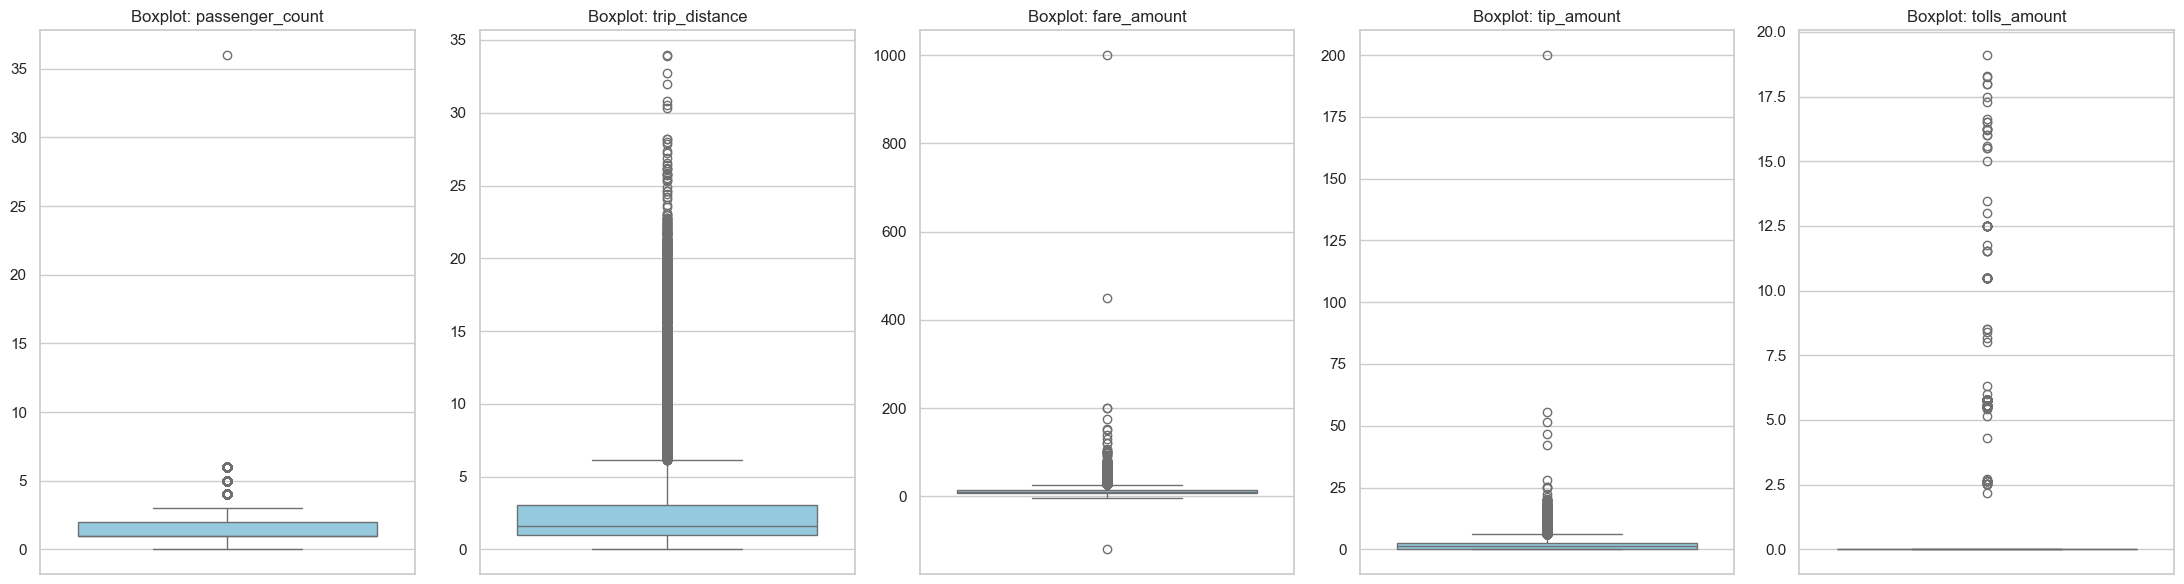

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5개 컬럼 리스트
cols = ['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount']

# 시각화 설정: 1행 5열로 구성
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, col in enumerate(cols):
    # sns.boxplot 호출
    # 위치 인자: df[col] (데이터 전달)
    # 키워드 인자: ax=axes[i], color='skyblue' (축 지정 및 색상)
    sns.boxplot(df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel('') # Y축 라벨 제거로 깔끔하게

plt.tight_layout()
plt.show()

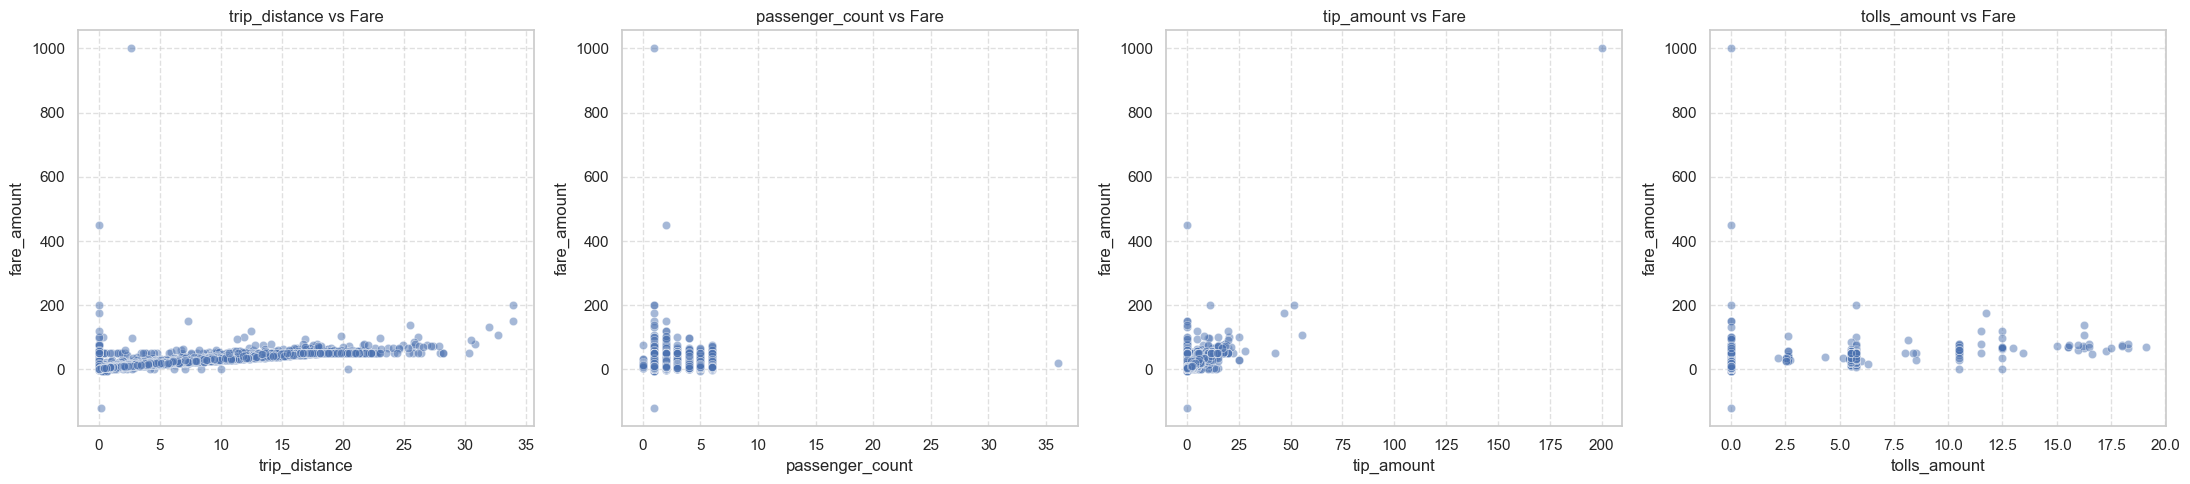

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# 요금과 비교할 대상 4개
compare_cols = ['trip_distance', 'passenger_count', 'tip_amount', 'tolls_amount']

# 시각화 설정: 1행 4열로 구성
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, col in enumerate(compare_cols):
    # sns.scatterplot 호출
    # 키워드 인자를 사용하여 가독성을 높임 (data, x, y, alpha 등)
    sns.scatterplot(data=df, x=col, y='fare_amount', ax=axes[i], alpha=0.5)
    
    axes[i].set_title(f'{col} vs Fare')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
################분석 결과, 승객 수, 요금에서 아웃라이어 발견##################

# 요금: 최소값 -120달러 존재, 최댓값 1000달러 존재 (기본 요금인 2.5 보다 작거나 300달러 이상 제거)
# 승객 수: 물리적으로 불가능한 35명 제거 (6명 이상)

# 삭제할 행이 얼마나 되는지 먼저 확인하자!

############################################################

# 1. 정제 조건 설정 (기존과 동일)
# 요금: 2.5 미만 또는 500 이상 제거
# 승객 수: 0 이하 또는 6 초과 제거
# 거리: 0 이하 데이터 제거
condition = (
    (df['fare_amount'] >= 2.5) & (df['fare_amount'] < 500) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6) &
    (df['trip_distance'] > 0)
)

# 2. 물결표(~)를 사용하여 조건의 '반대' 데이터만 추출
# 이것이 우리가 제거한(제거할) 아웃라이어들.
df_outliers = df[~condition].copy()

# 3. 결과 확인
print(f"총 삭제할 행의 수: {len(df_outliers)}")

# 삭제된 행 중 요금이나 승객 수가 튀는 것 위주로 상위 10개 확인
print("\n[삭제할 행 샘플]")
print(df_outliers[['passenger_count', 'trip_distance', 'fare_amount']].head(54))

# 삭제된 데이터의 통계값 확인 (우리가 의도한 대로 삭제됐는지 검증)
print("\n[삭제할 데이터의 통계 요약]")
print(df_outliers[['passenger_count', 'trip_distance', 'fare_amount']].describe())

총 삭제할 행의 수: 202

[삭제할 행 샘플]
      passenger_count  trip_distance  fare_amount
52                  1           2.20          NaN
64                 36           0.22        21.50
129                 1           0.00        20.00
189                 3          15.20          NaN
244                 1          15.89          NaN
248                 1           0.00         2.50
293                 1           0.00         2.50
316                 6           0.12        -2.50
321                 1           0.00         2.50
426                 1           0.00         2.50
472                 1           0.00        34.00
474                 1           0.00         9.50
574                 1           0.00        52.00
649                 1           0.00         2.50
797                 1           0.00         8.00
922                 1           0.00         2.50
1207                1           0.00         2.50
1277                1           0.00         2.50
1352                1 

In [81]:
########### 이제 실제 삭제 실행 #############


# # 1. 이상치 경계값 설정 (키워드 인자 활용)
FARE_MIN = 2.5
FARE_MAX = 500
PASS_MAX = 6

# 2. 정제 조건 설정 
# 요금: 2.5 미만 또는 500 이상 제거
# 승객 수: 0 이하 또는 6 초과 제거 (36명 등)
# 거리: 0 이하 데이터 제거
condition = (
    (df['fare_amount'] >= FARE_MIN) & (df['fare_amount'] < FARE_MAX) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= PASS_MAX) &
    (df['trip_distance'] > 0)
)

# 3. 데이터 분리 및 저장
# 조건의 반대(~)는 이상치로, 조건 만족은 정제 데이터로 할당
df_outliers = df[~condition].copy()
df_cleaned = df[condition].copy()

# 4. 실행 결과 출력 (기록형)
print(f"총 삭제 행 수: {len(df_outliers)}")
print(f"정제 후 행 수: {len(df_cleaned)}")

# 5. 삭제 대상 상세 확인 (상위 54개)
print("\n[삭제할 행 샘플]")
print(df_outliers[['passenger_count', 'trip_distance', 'fare_amount']].head(54))

# 6. 정제 결과 검증
print("\n[정제 후 데이터 통계 요약]")
print(df_cleaned[['passenger_count', 'trip_distance', 'fare_amount']].describe())

총 삭제 행 수: 202
정제 후 행 수: 22499

[삭제할 행 샘플]
      passenger_count  trip_distance  fare_amount
52                  1           2.20          NaN
64                 36           0.22        21.50
129                 1           0.00        20.00
189                 3          15.20          NaN
244                 1          15.89          NaN
248                 1           0.00         2.50
293                 1           0.00         2.50
316                 6           0.12        -2.50
321                 1           0.00         2.50
426                 1           0.00         2.50
472                 1           0.00        34.00
474                 1           0.00         9.50
574                 1           0.00        52.00
649                 1           0.00         2.50
797                 1           0.00         8.00
922                 1           0.00         2.50
1207                1           0.00         2.50
1277                1           0.00         2.50
1352    

In [62]:
# 1. 정제 조건 설정
# 요금: 2.5 이상 500 미만 (음수 및 1000달러 제거)
# 승객 수: 1명 이상 6명 이하 (0명 및 36명 제거)
# 거리: 0 초과 (주행 기록 있는 데이터)
condition = (
    (df['fare_amount'] >= 2.5) & (df['fare_amount'] < 500) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6) &
    (df['trip_distance'] > 0)
)

# 2. 원본 보존하며 새 변수(df_cleaned)에 저장
df_cleaned = df[condition].copy()

# 3. 결과 확인
print("--- 정제 결과 요약 ---")
print(f"원본 행 수: {len(df)}")
print(f"정제 후 행 수: {len(df_cleaned)}")
print(f"삭제된 행 수: {len(df) - len(df_cleaned)}")

# 4. 데이터 정보 및 통계 확인
print("\n[df_cleaned 정보]")
df_cleaned.info()

print("\n[df_cleaned 통계 요약]")
print(df_cleaned[['passenger_count', 'trip_distance', 'fare_amount']].describe())

--- 정제 결과 요약 ---
원본 행 수: 22553
정제 후 행 수: 22499
삭제된 행 수: 54

[df_cleaned 정보]
<class 'pandas.core.frame.DataFrame'>
Index: 22499 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22499 non-null  object 
 1   tpep_pickup_datetime   22499 non-null  object 
 2   tpep_dropoff_datetime  22499 non-null  object 
 3   payment_method         22499 non-null  object 
 4   passenger_count        22499 non-null  int64  
 5   trip_distance          22499 non-null  float64
 6   fare_amount            22499 non-null  float64
 7   tip_amount             22499 non-null  float64
 8   tolls_amount           22499 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.7+ MB

[df_cleaned 통계 요약]
       passenger_count  trip_distance   fare_amount
count     22499.000000   22499.000000  22499.000000
mean          1.645806       2.932655     12.931469
std        

In [83]:
df_cleaned.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22499.000000,22499.000000,22499.000000,22499.000000,22499.000000
mean,1.645806,2.932655,12.931469,1.822051,0.308823
std,1.285539,3.656020,10.825465,2.431889,1.383723
min,1.000000,0.010000,2.500000,0.000000,0.000000
25%,1.000000,1.000000,6.500000,0.000000,0.000000
50%,1.000000,1.630000,9.500000,1.360000,0.000000
75%,2.000000,3.095000,14.500000,2.450000,0.000000
max,6.000000,33.960000,200.010000,55.500000,19.100000


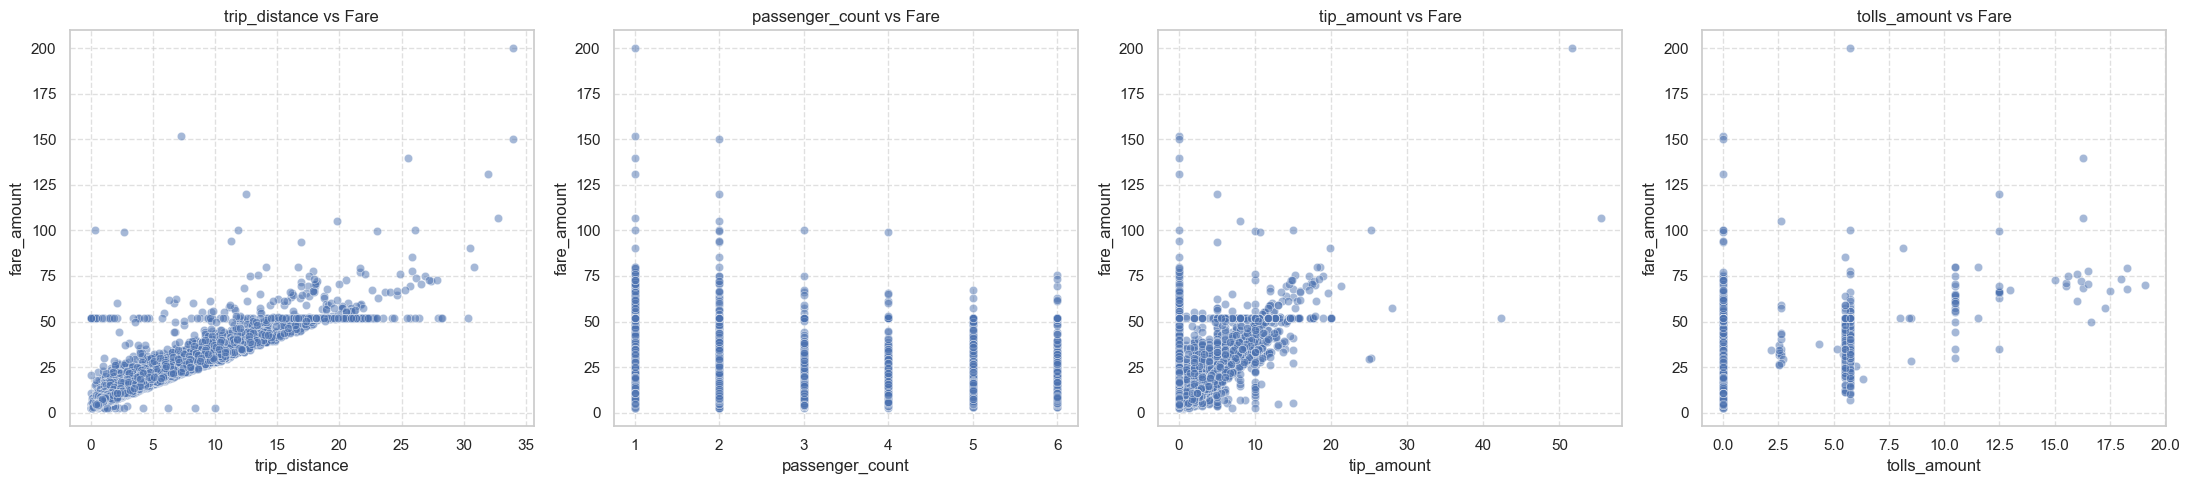

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# 요금과 비교할 대상 4개
compare_cols = ['trip_distance', 'passenger_count', 'tip_amount', 'tolls_amount']

# 시각화 설정: 1행 4열로 구성
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, col in enumerate(compare_cols):
    # sns.scatterplot 호출
    # 키워드 인자를 사용하여 가독성을 높임 (data, x, y, alpha 등)
    sns.scatterplot(data=df_cleaned, x=col, y='fare_amount', ax=axes[i], alpha=0.5)
    
    axes[i].set_title(f'{col} vs Fare')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

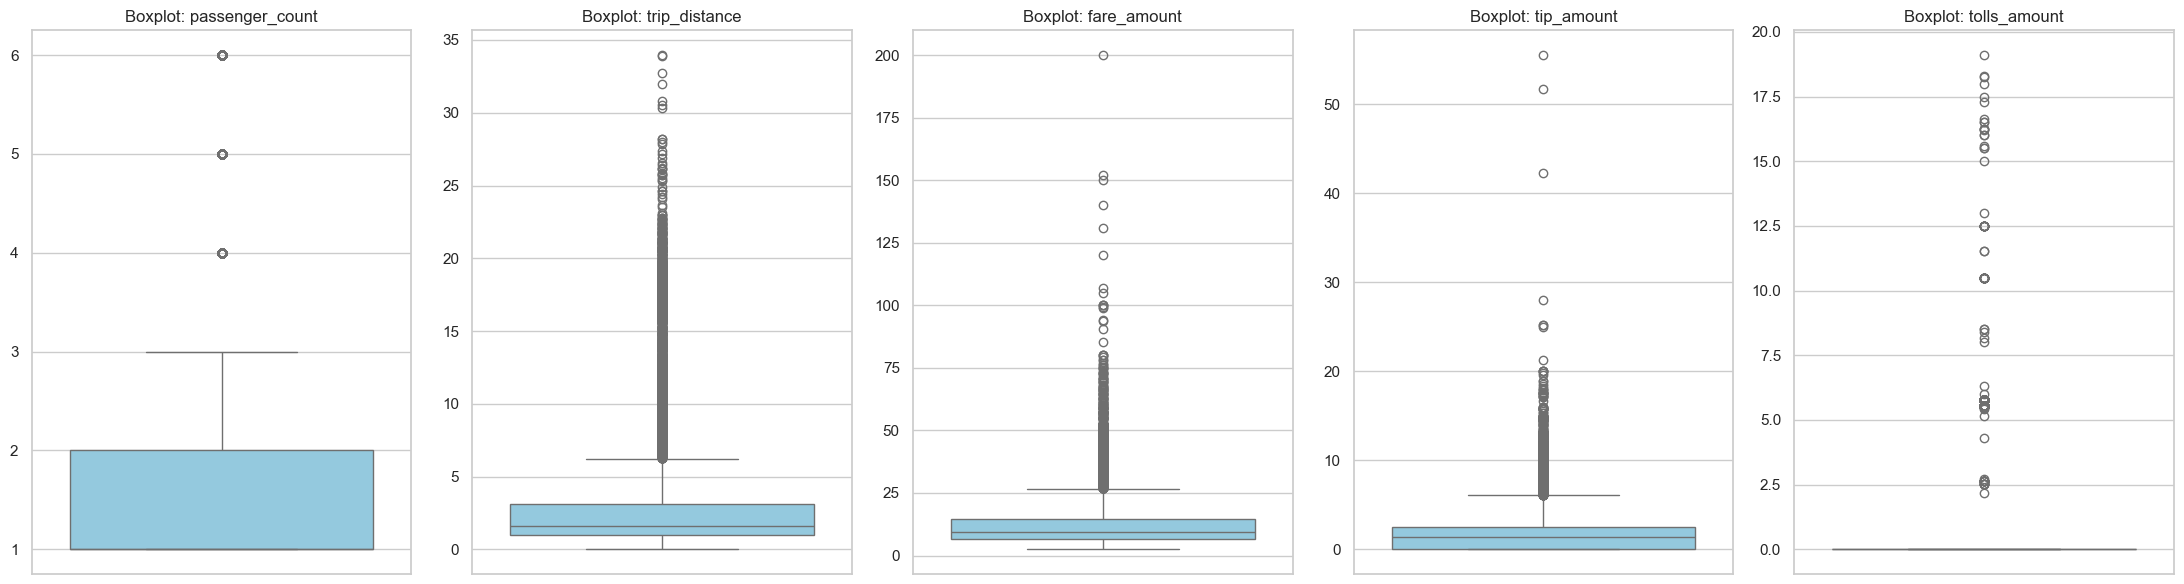

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5개 컬럼 리스트
cols = ['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount']

# 시각화 설정: 1행 5열로 구성
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, col in enumerate(cols):
    # sns.boxplot 호출
    # 위치 인자: df[col] (데이터 전달)
    # 키워드 인자: ax=axes[i], color='skyblue' (축 지정 및 색상)
    sns.boxplot(df_cleaned[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel('') # Y축 라벨 제거로 깔끔하게

plt.tight_layout()
plt.show()

데이터 클린업 완료!!!

## 상관관계 분석

In [117]:
#택시 탑승 및 하차 시간을 활용할 수 있을지 고민해보세요.
#[힌트] 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?
#Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.

In [92]:
df_cleaned.corr(numeric_only = True)


,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
passenger_count,1.000000,0.015496,0.015017,-0.008775,0.009750
trip_distance,0.015496,1.000000,0.936148,0.583736,0.633062
fare_amount,0.015017,0.936148,1.000000,0.600282,0.622749
tip_amount,-0.008775,0.583736,0.600282,1.000000,0.475748
tolls_amount,0.009750,0.633062,0.622749,0.475748,1.000000


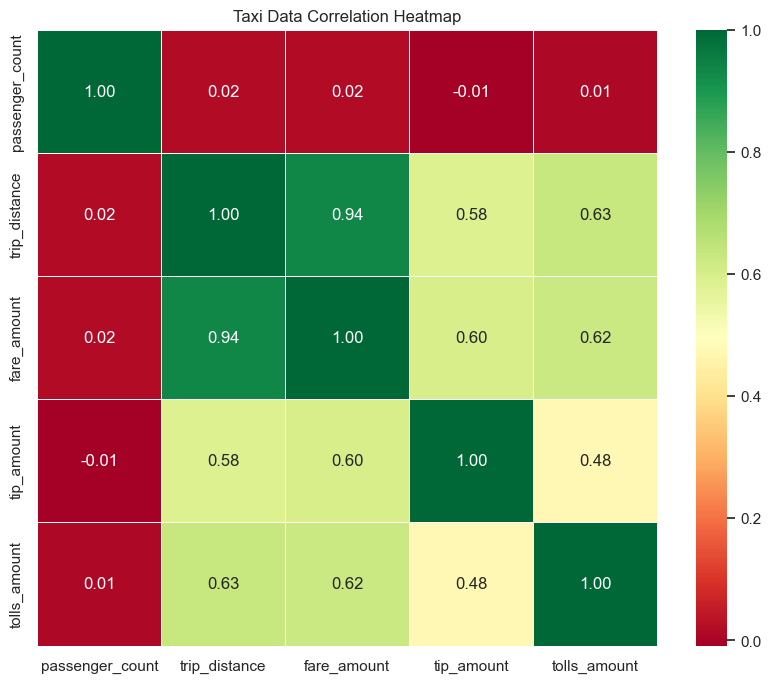

In [93]:
# 1. 상관계수 계산 (문자열 컬럼 제외를 위해 numeric_only=True 사용)
corr = df_cleaned.corr(numeric_only=True)

# 2. 히트맵 시각화 설정
plt.figure(figsize=(10, 8))

# sns.heatmap 호출 방식 분석:
# - 위치 인자: corr (첫 번째 자리에 데이터 전달)
# - 키워드 인자: annot=True, cmap='RdYlGn', fmt='.2f' (이름표와 함께 옵션 전달)
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

plt.title('Taxi Data Correlation Heatmap')
plt.show()

In [94]:
# 주행 거리과 요금, 톨 비용, 요금과 팁 등은 너무 당연한 관계.
# 인사이트를 얻기 위해서는 상관관계에 대한 가설과 파생 파라미터 파악이 필요

## EDA

### - 하루 중 언제가 가장 수익률이 좋은가?

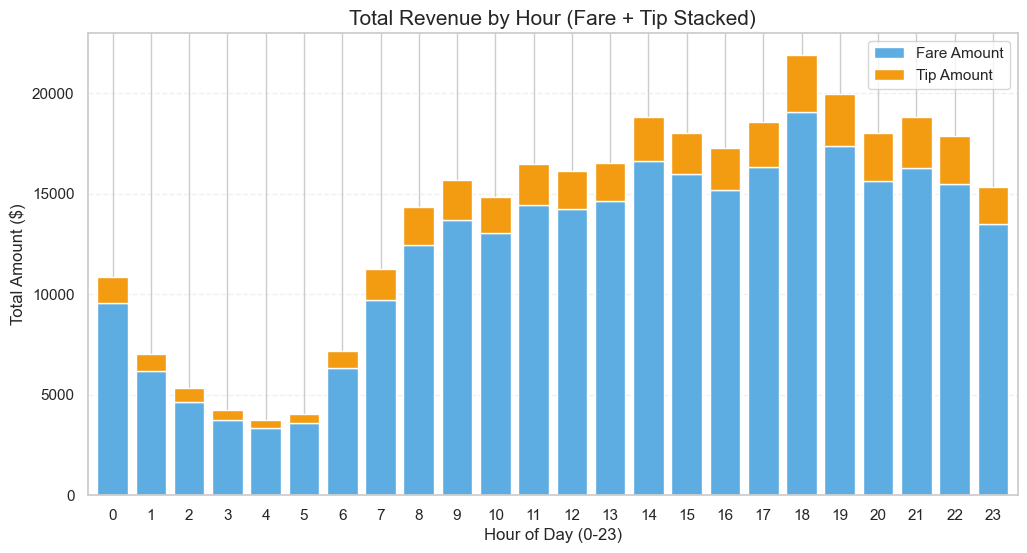

In [99]:
import matplotlib.pyplot as plt

# 1. 시간 데이터 변환 및 시간대 추출
df_cleaned['tpep_pickup_datetime'] = pd.to_datetime(df_cleaned['tpep_pickup_datetime'])
df_cleaned['pickup_hour'] = df_cleaned['tpep_pickup_datetime'].dt.hour

# 2. 시간대별로 요금과 팁의 '합계'를 계산 (나래비 세우기)
# groupby의 첫 번째 인자로 'pickup_hour'를 위치 인자로 전달했습니다.
hourly_revenue = df_cleaned.groupby('pickup_hour')[['fare_amount', 'tip_amount']].sum()

# 3. 스택 바 차트 시각화
# - 위치 인자: hourly_revenue (데이터 자체)
# - 키워드 인자: stacked=True, color=['#5dade2', '#f39c12'] 등 (옵션 명시)
ax = hourly_revenue.plot(
    kind='bar', 
    stacked=True, 
    color=['#5dade2', '#f39c12'], # 요금은 하늘색, 팁은 오렌지색
    figsize=(12, 6), 
    width=0.8
)

plt.title('Total Revenue by Hour (Fare + Tip Stacked)', fontsize=15)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Total Amount ($)', fontsize=12)
plt.xticks(rotation=0) # 시간 숫자를 가로로 바르게 세움
plt.legend(['Fare Amount', 'Tip Amount'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

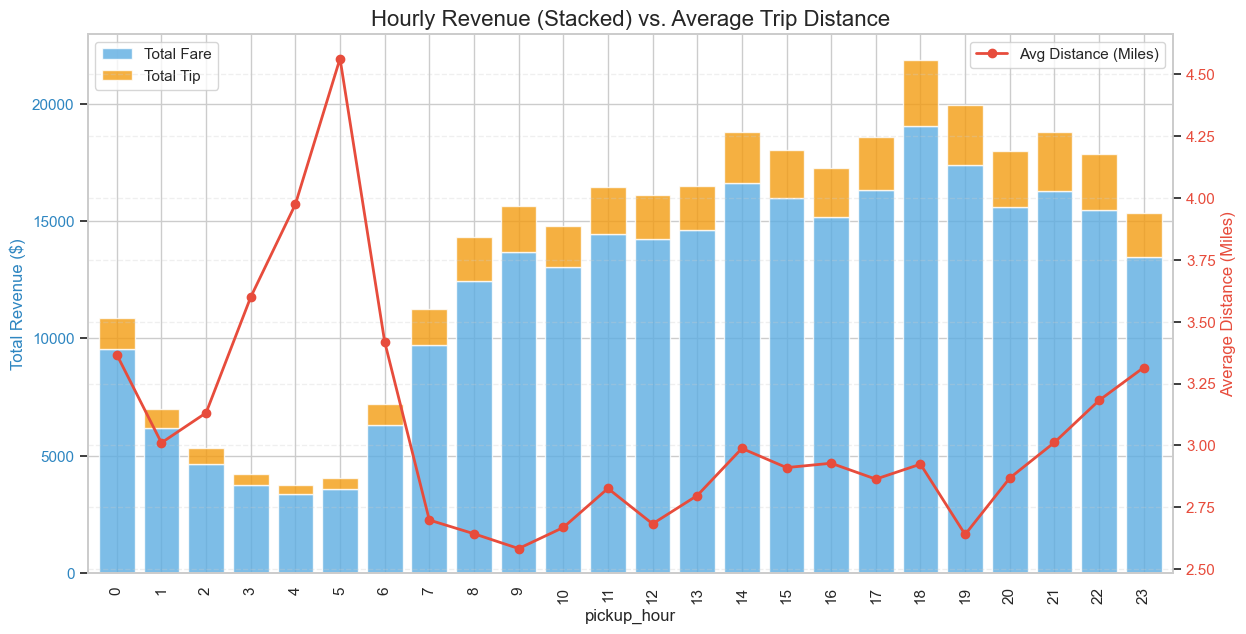

In [100]:
import matplotlib.pyplot as plt

# 1. 시간대별 데이터 집계 (합계와 평균을 동시에!)
hourly_stats = df_cleaned.groupby('pickup_hour').agg(
    total_fare=('fare_amount', 'sum'),
    total_tip=('tip_amount', 'sum'),
    avg_distance=('trip_distance', 'mean')
)

# 2. 그래프 생성
fig, ax1 = plt.subplots(figsize=(14, 7))

# [왼쪽 Y축] 요금과 팁을 쌓은 막대 그래프
# 키워드 인자: stacked=True, color=['#5dade2', '#f39c12']
hourly_stats[['total_fare', 'total_tip']].plot(
    kind='bar', 
    stacked=True, 
    ax=ax1, 
    color=['#5dade2', '#f39c12'], 
    alpha=0.8,
    width=0.8
)
ax1.set_ylabel('Total Revenue ($)', fontsize=12, color='#2e86c1')
ax1.tick_params(axis='y', labelcolor='#2e86c1')
ax1.legend(['Total Fare', 'Total Tip'], loc='upper left')

# [오른쪽 Y축] 평균 주행 거리를 나타내는 선 그래프
# twinx()를 사용하여 왼쪽과 축을 공유하지만 Y축 스케일은 따로 가져갑니다.
ax2 = ax1.twinx()
ax2.plot(
    hourly_stats.index, 
    hourly_stats['avg_distance'], 
    color='#e74c3c', # 강렬한 빨간색 선
    marker='o', 
    linewidth=2, 
    label='Avg Distance (Miles)'
)
ax2.set_ylabel('Average Distance (Miles)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.legend(loc='upper right')

plt.title('Hourly Revenue (Stacked) vs. Average Trip Distance', fontsize=16)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

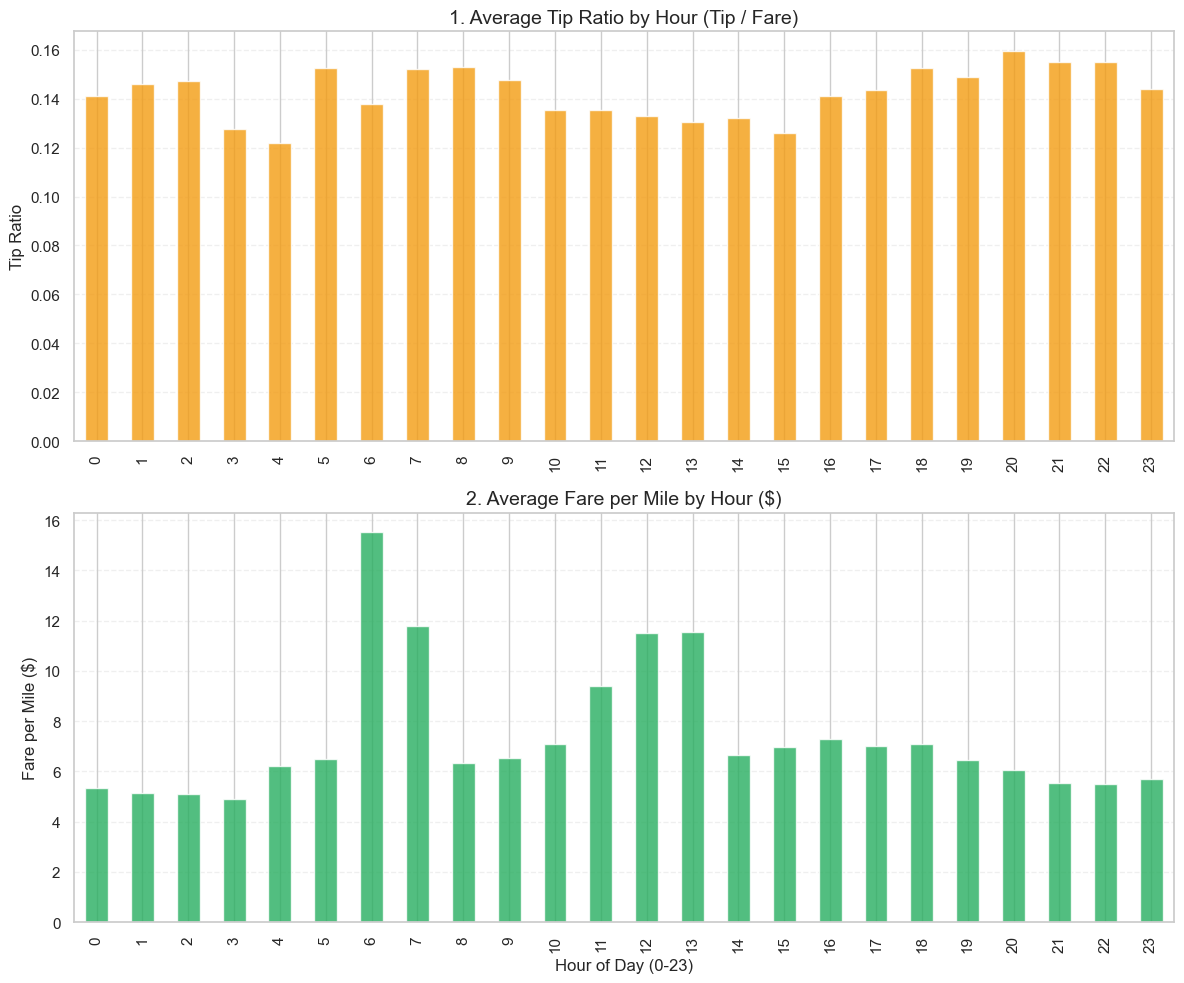

In [101]:
# 1. 파생 변수 생성 (계산을 위해 새로운 컬럼 추가)
# 팁 비중: 요금 대비 팁이 차지하는 비율
df_cleaned['tip_ratio'] = df_cleaned['tip_amount'] / df_cleaned['fare_amount']
# 마일당 수익: 주행 거리 1마일당 벌어들이는 요금
df_cleaned['fare_per_mile'] = df_cleaned['fare_amount'] / df_cleaned['trip_distance']

# 2. 시간대별 평균(mean) 계산
# 위치 인자 'pickup_hour'를 사용하여 그룹화합니다.
hourly_metrics = df_cleaned.groupby('pickup_hour')[['tip_ratio', 'fare_per_mile']].mean()

# 3. 시각화 (1행 2열 구조로 심플하게 비교)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# 그래프 1: 시간대별 평균 팁 비중
# 키워드 인자들을 사용하여 스타일을 지정했습니다.
hourly_metrics['tip_ratio'].plot(kind='bar', ax=ax1, color='#f39c12', alpha=0.8)
ax1.set_title('1. Average Tip Ratio by Hour (Tip / Fare)', fontsize=14)
ax1.set_ylabel('Tip Ratio')
ax1.set_xlabel('') # 하단 그래프와 겹치지 않게 비움
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 그래프 2: 시간대별 마일당 수익
hourly_metrics['fare_per_mile'].plot(kind='bar', ax=ax2, color='#27ae60', alpha=0.8)
ax2.set_title('2. Average Fare per Mile by Hour ($)', fontsize=14)
ax2.set_ylabel('Fare per Mile ($)')
ax2.set_xlabel('Hour of Day (0-23)')
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 분석 결과
# 1. 뉴욕 택시의 강력한 '팁 규칙' (Social Norm)
# 현상: 시간대에 관계없이 팁 비율이 12%~16% 사이에서 평탄하게 유지되고 있다.
# 해석: 
# 승객들이 기분이나 상황에 따라 팁을 주는 것이 아니라, 
# "택시 요금의 약 15% 정도는 팁으로 내야 한다"는 사회적 관습(Social Norm)이 매우 강력하게 자리 잡고 있음을 의미한다.
# 즉, 팁은 '선택'이 아닌 '고정 비용'에 가깝게 작동하고 있다.


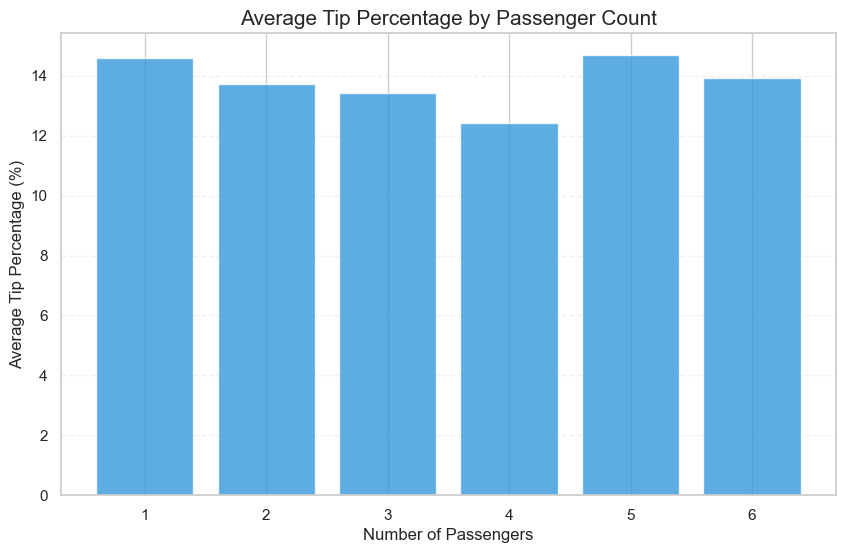

passenger_count
1    14.599386
2    13.734737
3    13.420402
4    12.410667
5    14.683415
6    13.924905
Name: tip_percentage, dtype: float64


In [102]:
import matplotlib.pyplot as plt

# 1. 팁 비중(%) 컬럼 생성
df_cleaned['tip_percentage'] = (df_cleaned['tip_amount'] / df_cleaned['fare_amount']) * 100

# 2. 승객 수별 평균 팁 비중 계산
# 위치 인자 'passenger_count'를 기준으로 그룹화합니다.
passenger_tips = df_cleaned.groupby('passenger_count')['tip_percentage'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))

# plt.bar 호출 방식:
# - 위치 인자: passenger_tips.index, passenger_tips.values (X축과 Y축 데이터)
# - 키워드 인자: color='#3498db', alpha=0.8 (스타일 옵션)
plt.bar(passenger_tips.index, passenger_tips.values, color='#3498db', alpha=0.8)

plt.title('Average Tip Percentage by Passenger Count', fontsize=15)
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Average Tip Percentage (%)', fontsize=12)
plt.xticks(range(1, 7)) # 승객 수는 1~6명
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# 데이터 수치 확인
print(passenger_tips)

In [103]:
# 승객 수에 따른 팁 비율도 크게 차이가 없는 것으로 확인되었다.

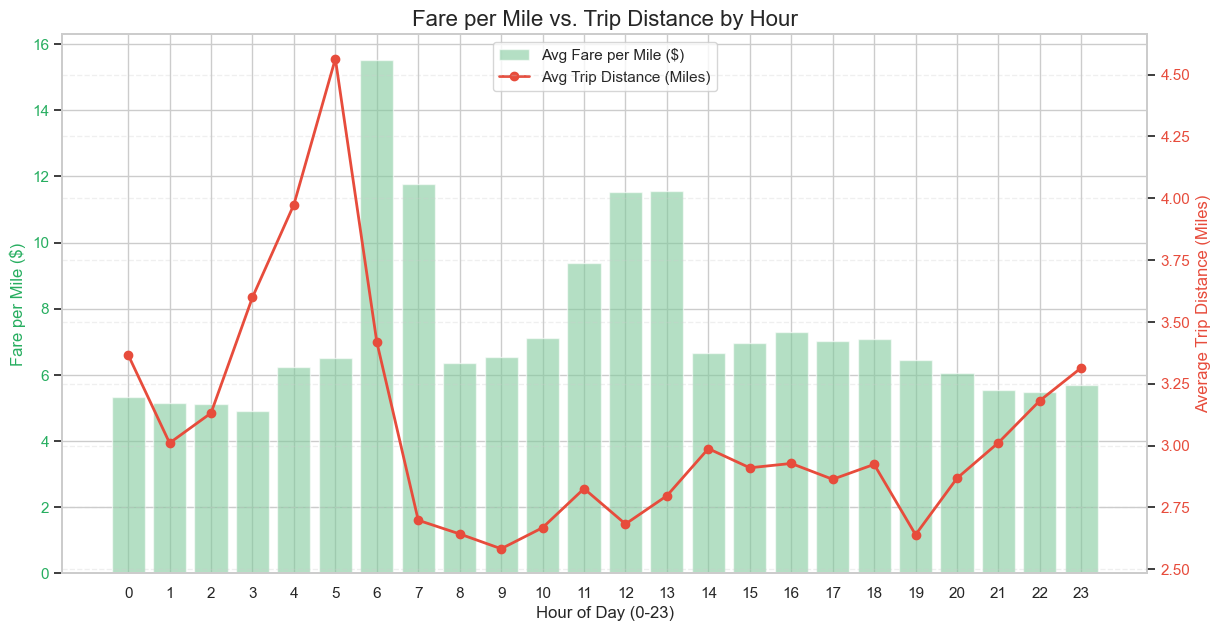

In [104]:
import matplotlib.pyplot as plt

# 1. 시간대별 평균 데이터 집계
hourly_analysis = df_cleaned.groupby('pickup_hour').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean'),
    avg_trip_distance=('trip_distance', 'mean')
)

# 2. 이중 Y축 그래프 생성
fig, ax1 = plt.subplots(figsize=(14, 7))

# [왼쪽 Y축] 마일당 수익 (막대 그래프)
ax1.bar(hourly_analysis.index, hourly_analysis['avg_fare_per_mile'], color='#82ca9d', alpha=0.6, label='Avg Fare per Mile ($)')
ax1.set_ylabel('Fare per Mile ($)', fontsize=12, color='#27ae60')
ax1.tick_params(axis='y', labelcolor='#27ae60')

# [오른쪽 Y축] 평균 주행 거리 (선 그래프)
ax2 = ax1.twinx()
ax2.plot(hourly_analysis.index, hourly_analysis['avg_trip_distance'], color='#e74c3c', marker='o', linewidth=2, label='Avg Trip Distance (Miles)')
ax2.set_ylabel('Average Trip Distance (Miles)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('Fare per Mile vs. Trip Distance by Hour', fontsize=16)
plt.xticks(range(0, 24))
ax1.set_xlabel('Hour of Day (0-23)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 범례 통합 표시
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center')

plt.show()

In [108]:
######### 결론  #########
# 효율성 지표의 역설: '마일당 수익(Fare per Mile)'과 '평균 주행 거리(Average Trip Distance)'는 음의 상관관계를 가진다. 즉, 멀리 갈수록 마일당 벌어들이는 수익 효율은 떨어진다.
# 수익 최적화 구간: 6~7시 및 11~13시 구간에서 마일당 수익률이 가장 높게 나타난다.
# 원인: 해당 시간대의 높은 수익률은 장거리 운행이 아닌, 단거리 운행의 반복을 통한 높은 회전율이 주된 원인임을 데이터를 통해 증명하였다.

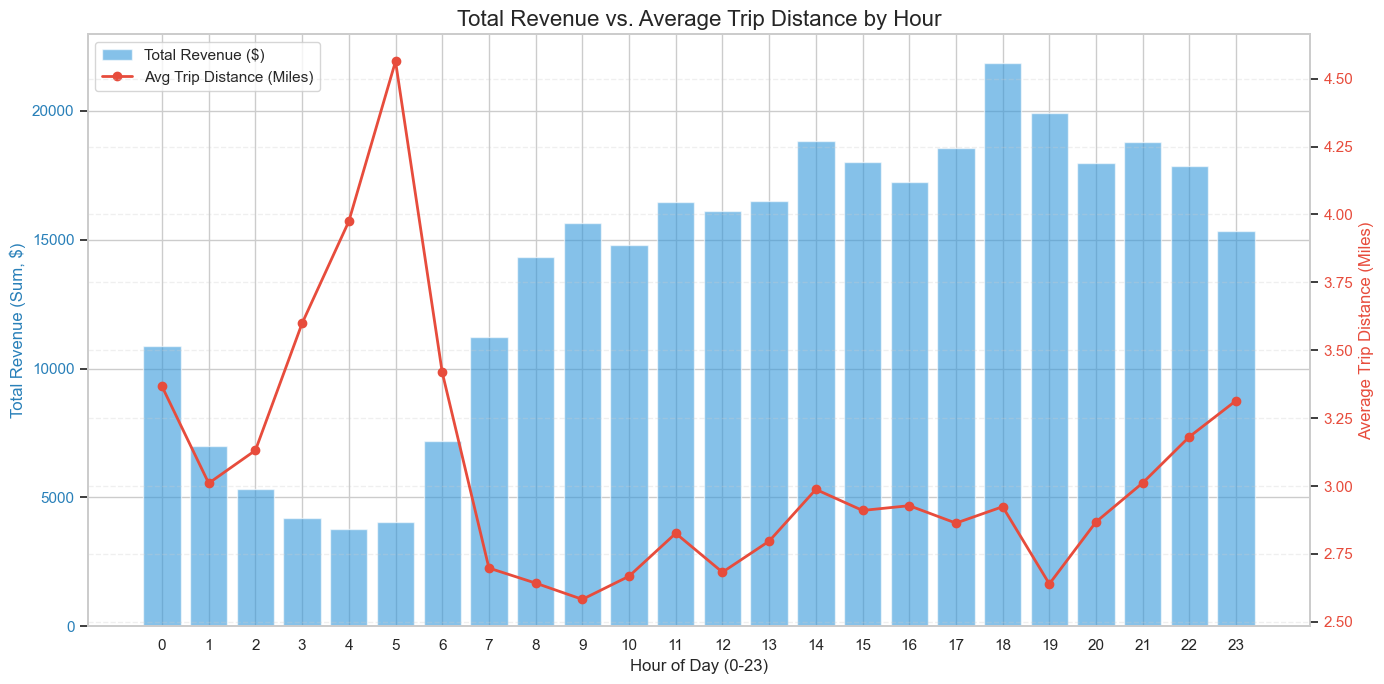

In [109]:
import matplotlib.pyplot as plt

# 1. 에러 방지를 위한 필수 파생 변수 생성
# 총 수익(요금+팁) 및 마일당 수익 계산
df_cleaned['total_revenue'] = df_cleaned['fare_amount'] + df_cleaned['tip_amount']
df_cleaned['fare_per_mile'] = df_cleaned['fare_amount'] / df_cleaned['trip_distance']

# 2. 시간대별 통계량 집계
# 총 수익은 합계(sum)를, 주행 거리는 평균(mean)을 산출
hourly_analysis = df_cleaned.groupby('pickup_hour').agg(
    total_revenue_sum=('total_revenue', 'sum'),
    avg_trip_distance=('trip_distance', 'mean')
).sort_index()

# 3. 이중 Y축 그래프 시각화
fig, ax1 = plt.subplots(figsize=(14, 7))

# [왼쪽 Y축] 총 수익 합계 (막대 그래프)
ax1.bar(hourly_analysis.index, hourly_analysis['total_revenue_sum'], 
        color='#3498db', alpha=0.6, label='Total Revenue ($)')
ax1.set_ylabel('Total Revenue (Sum, $)', fontsize=12, color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax1.set_xlabel('Hour of Day (0-23)', fontsize=12)

# [오른쪽 Y축] 평균 주행 거리 (선 그래프)
ax2 = ax1.twinx()
ax2.plot(hourly_analysis.index, hourly_analysis['avg_trip_distance'], 
         color='#e74c3c', marker='o', linewidth=2, label='Avg Trip Distance (Miles)')
ax2.set_ylabel('Average Trip Distance (Miles)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# 그래프 스타일 및 범례 설정
plt.title('Total Revenue vs. Average Trip Distance by Hour', fontsize=16)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 두 축의 범례를 하나로 통합
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

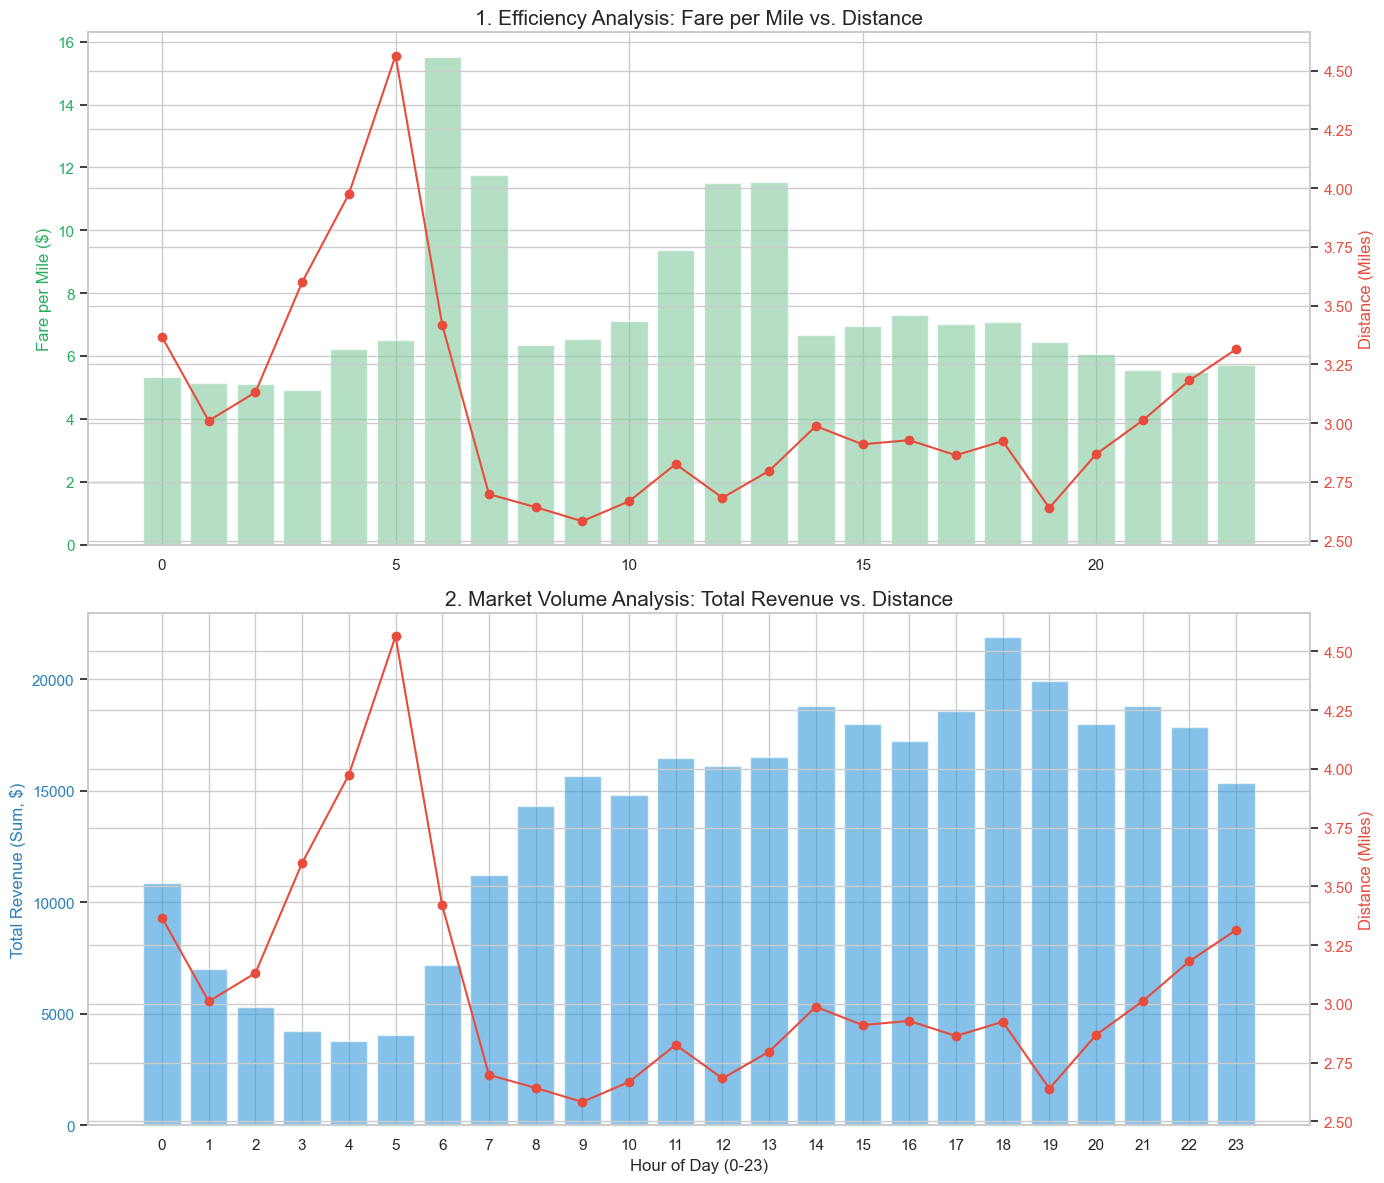

In [110]:
import matplotlib.pyplot as plt

# 1. 파생 변수 및 집계 데이터 준비 (df_cleaned 사용 가정)
df_cleaned['total_revenue'] = df_cleaned['fare_amount'] + df_cleaned['tip_amount']
df_cleaned['fare_per_mile'] = df_cleaned['fare_amount'] / df_cleaned['trip_distance']

hourly_stats = df_cleaned.groupby('pickup_hour').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean'),
    total_revenue_sum=('total_revenue', 'sum'),
    avg_trip_distance=('trip_distance', 'mean')
).sort_index()

# 2. 상하 2단 그래프 생성
fig, (ax1_top, ax1_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# --- 상단: 마일당 요금(효율) vs 평균 주행 거리 ---
ax1_top.bar(hourly_stats.index, hourly_stats['avg_fare_per_mile'], color='#82ca9d', alpha=0.6, label='Avg Fare per Mile ($)')
ax1_top.set_ylabel('Fare per Mile ($)', color='#27ae60', fontsize=12)
ax1_top.tick_params(axis='y', labelcolor='#27ae60')
ax1_top.set_title('1. Efficiency Analysis: Fare per Mile vs. Distance', fontsize=15)

ax2_top = ax1_top.twinx()
ax2_top.plot(hourly_stats.index, hourly_stats['avg_trip_distance'], color='#e74c3c', marker='o', label='Avg Distance (Miles)')
ax2_top.set_ylabel('Distance (Miles)', color='#e74c3c', fontsize=12)
ax2_top.tick_params(axis='y', labelcolor='#e74c3c')

# --- 하단: 총 수익(규모) vs 평균 주행 거리 ---
ax1_bottom.bar(hourly_stats.index, hourly_stats['total_revenue_sum'], color='#3498db', alpha=0.6, label='Total Revenue ($)')
ax1_bottom.set_ylabel('Total Revenue (Sum, $)', color='#2980b9', fontsize=12)
ax1_bottom.tick_params(axis='y', labelcolor='#2980b9')
ax1_bottom.set_title('2. Market Volume Analysis: Total Revenue vs. Distance', fontsize=15)
ax1_bottom.set_xlabel('Hour of Day (0-23)', fontsize=12)

ax2_bottom = ax1_bottom.twinx()
ax2_bottom.plot(hourly_stats.index, hourly_stats['avg_trip_distance'], color='#e74c3c', marker='o', label='Avg Distance (Miles)')
ax2_bottom.set_ylabel('Distance (Miles)', color='#e74c3c', fontsize=12)
ax2_bottom.tick_params(axis='y', labelcolor='#e74c3c')

# 레이아웃 정리
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

#### 분석 내용:
-  시간대별 마일당 수익률은 6~7시 및 11~13시 구간에서 이 가장 높지만,
-  전체 수익은 18시를 피크로 아침 8-9시 부터 23시까지 넓게 분포되어 있다.

### - 주말과 평일의 운행 관계는?

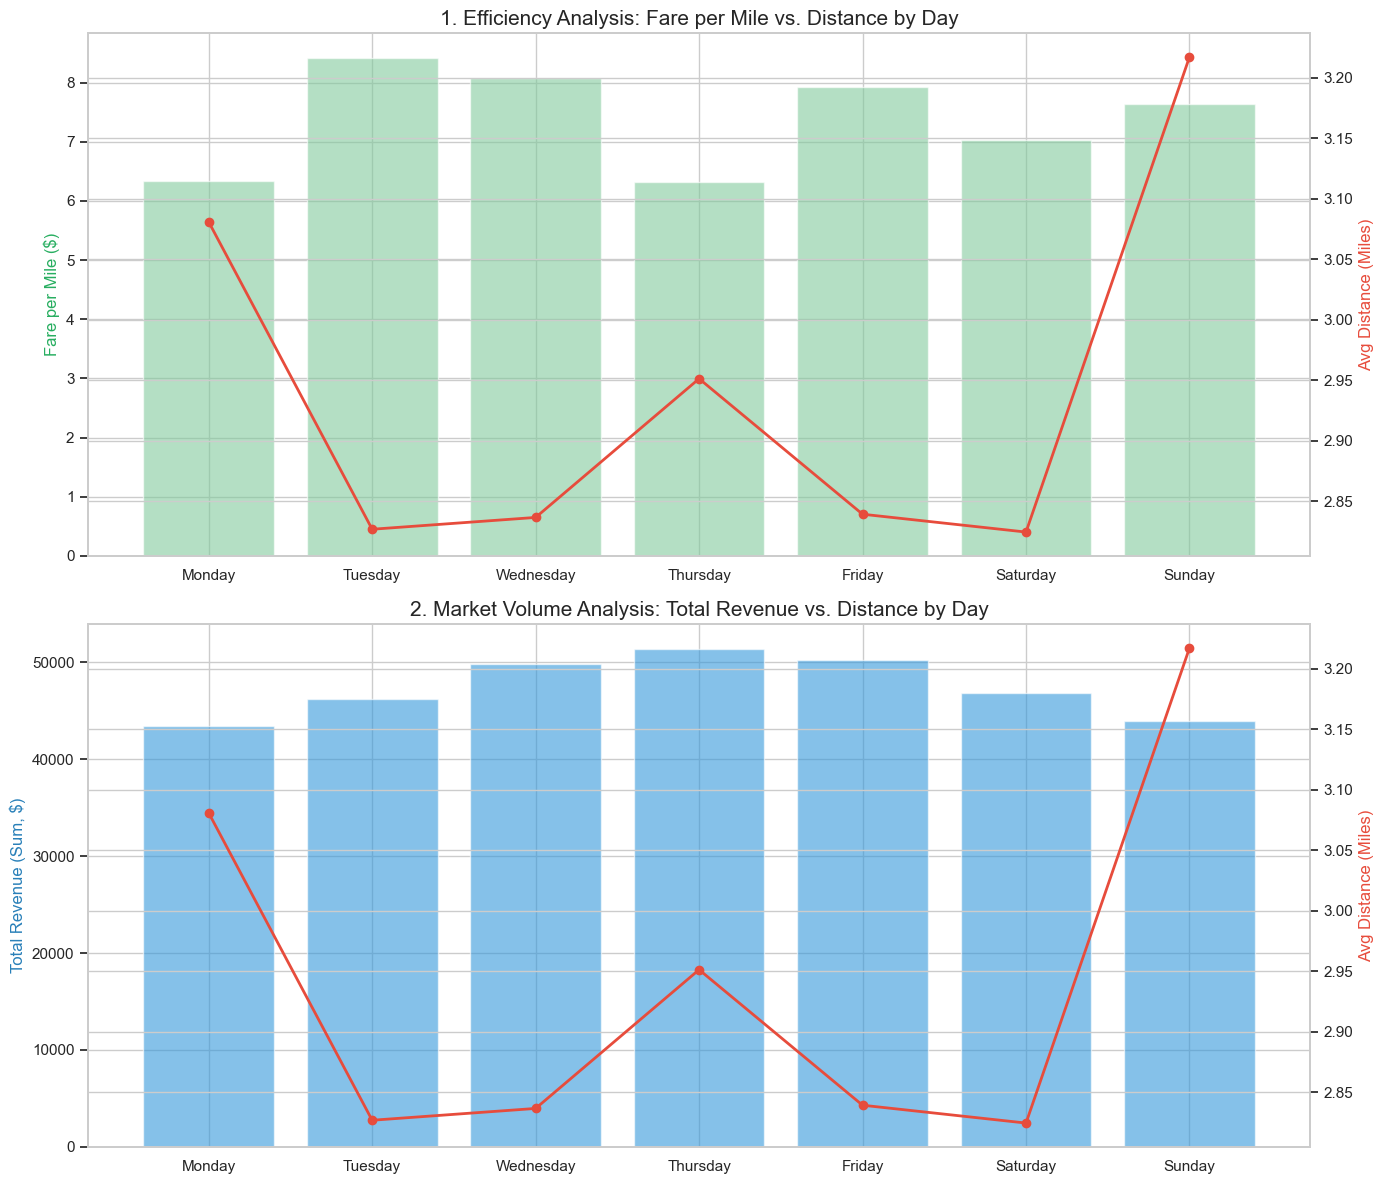

In [ ]:
# 주말과 평일의 운행 관계는?

# 1. 날짜 데이터에서 요일 추출 (0=월요일, 6=일요일)
df_cleaned['tpep_pickup_datetime'] = pd.to_datetime(df_cleaned['tpep_pickup_datetime'])
df_cleaned['day_of_week'] = df_cleaned['tpep_pickup_datetime'].dt.dayofweek
df_cleaned['day_name'] = df_cleaned['tpep_pickup_datetime'].dt.day_name()

# 2. 요일별 데이터 집계
day_stats = df_cleaned.groupby(by='day_of_week').agg(
    total_revenue_sum=('total_revenue', 'sum'),
    avg_fare_per_mile=('fare_per_mile', 'mean'),
    avg_trip_distance=('trip_distance', 'mean'),
    day_label=('day_name', 'first')
).sort_index()

# 3. 상하 2단 그래프 시각화
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))
days = day_stats['day_label'].tolist()

# --- 상단: 요일별 마일당 수익(효율) vs 평균 거리 ---
ax1.bar(day_stats.index, day_stats['avg_fare_per_mile'], color='#82ca9d', alpha=0.6)
ax1.set_ylabel('Fare per Mile ($)', color='#27ae60')
ax1.set_title('1. Efficiency Analysis: Fare per Mile vs. Distance by Day', fontsize=15)
ax1.set_xticks(day_stats.index)
ax1.set_xticklabels(days)

ax1_twin = ax1.twinx()
ax1_twin.plot(day_stats.index, day_stats['avg_trip_distance'], color='#e74c3c', marker='o', linewidth=2)
ax1_twin.set_ylabel('Avg Distance (Miles)', color='#e74c3c')

# --- 하단: 요일별 총 수익(규모) vs 평균 거리 ---
ax2.bar(day_stats.index, day_stats['total_revenue_sum'], color='#3498db', alpha=0.6)
ax2.set_ylabel('Total Revenue (Sum, $)', color='#2980b9')
ax2.set_title('2. Market Volume Analysis: Total Revenue vs. Distance by Day', fontsize=15)
ax2.set_xticks(day_stats.index)
ax2.set_xticklabels(days)

ax2_twin = ax2.twinx()
ax2_twin.plot(day_stats.index, day_stats['avg_trip_distance'], color='#e74c3c', marker='o', linewidth=2)
ax2_twin.set_ylabel('Avg Distance (Miles)', color='#e74c3c')

plt.tight_layout()
plt.show()

#### 분석 내용:
- 주중에는 단거리 운행을, 주말에는 장거리 운행을 함을 알 수 있고, 총 revenue에는 큰 차이가 없다.

### 카드와 현금 지불, 어떤 차이를 만들까?

기존 유니크 값: ['Debit Card' 'Cash' 'Credit Card']


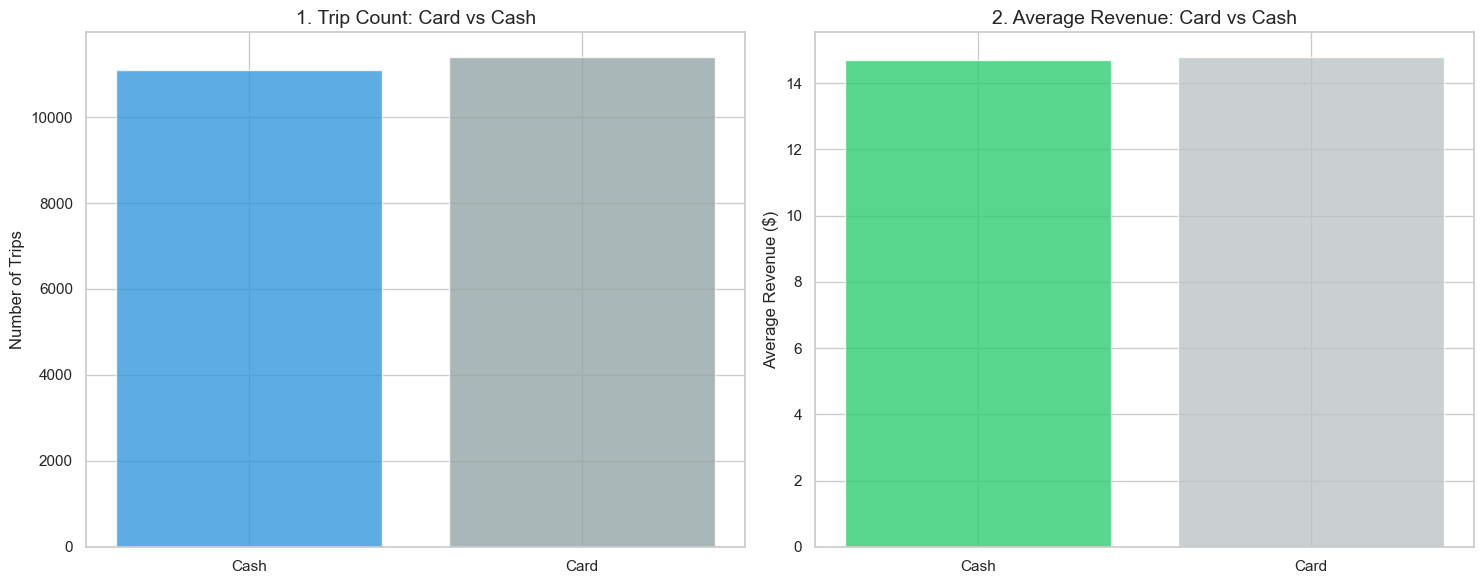

--- 재분류 후 결제 수단별 통계 ---
               trip_count  avg_revenue
payment_group                         
Cash                11096    14.707723
Card                11403    14.798084


In [ ]:
# 1. 세 가지 유니크한 값을 두 그룹으로 재분류
# 데이터셋의 실제 값에 따라 매핑 (예: Credit card, Debit card -> Card / Cash -> Cash)
# 실제 값 확인을 위해 unique()를 먼저 참조하는 로직을 포함 
unique_methods = df_cleaned['payment_method'].unique()
print(f"기존 유니크 값: {unique_methods}")

# 매핑 딕셔너리 생성 (디지털 결제 수단들을 'Card'로 통합)
def categorize_payment(method):
    method = str(method).lower()
    if 'cash' in method:
        return 'Cash'
    else:
        return 'Card' # 그 외(Credit, Debit, Mobile 등)는 모두 Card로 분류

df_cleaned['payment_group'] = df_cleaned['payment_method'].apply(categorize_payment)

# 2. 요약 통계량 집계 (운행 건수 및 평균 수익)
payment_stats = df_cleaned.groupby('payment_group').agg(
    trip_count=('payment_group', 'count'),
    avg_revenue=('total_revenue', 'mean')
).sort_index(ascending=False) # Card, Cash 순 정렬

# 3. 시각화 (좌: 운행 건수, 우: 평균 수익)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# [왼쪽] 어떤 결제 수단이 더 많이 사용되는가?
ax1.bar(payment_stats.index, payment_stats['trip_count'], color=['#3498db', '#95a5a6'], alpha=0.8)
ax1.set_title('1. Trip Count: Card vs Cash', fontsize=14)
ax1.set_ylabel('Number of Trips')

# [오른쪽] 어떤 결제 수단의 수익이 더 높은가?
ax2.bar(payment_stats.index, payment_stats['avg_revenue'], color=['#2ecc71', '#bdc3c7'], alpha=0.8)
ax2.set_title('2. Average Revenue: Card vs Cash', fontsize=14)
ax2.set_ylabel('Average Revenue ($)')

plt.tight_layout()
plt.show()

print("--- 재분류 후 결제 수단별 통계 ---")
print(payment_stats)

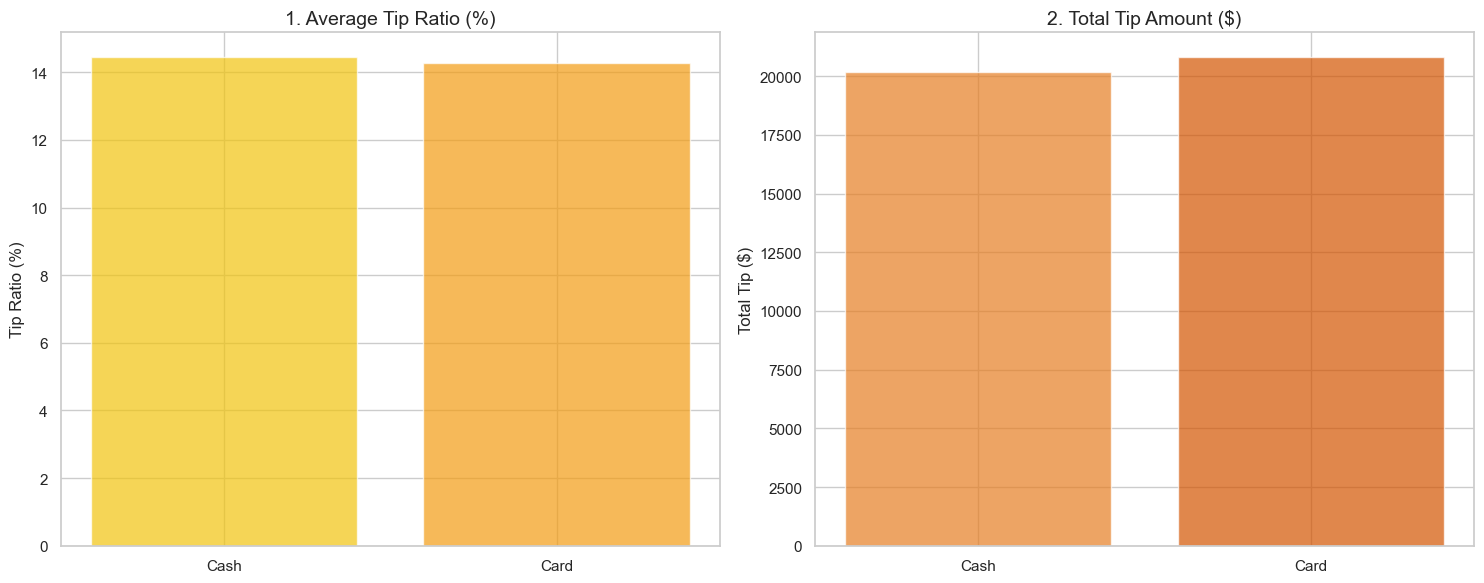

               avg_tip_ratio  total_tip_sum
payment_group                              
Cash                0.144560       20172.14
Card                0.142735       20822.19


In [118]:
import matplotlib.pyplot as plt

# 1. 팁 관련 지표 계산 (Card vs Cash 재분류 사용)
df_cleaned['tip_ratio'] = df_cleaned['tip_amount'] / df_cleaned['fare_amount']

# 2. 그룹별 집계 (평균 팁 비율 및 팁 합계)
tip_comparison = df_cleaned.groupby('payment_group').agg(
    avg_tip_ratio=('tip_ratio', 'mean'),
    total_tip_sum=('tip_amount', 'sum')
).sort_index(ascending=False) # Card, Cash 순

# 3. 시각화 (1행 2열 구조)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# [왼쪽] 평균 팁 비율 (%)
# 위치 인자: tip_comparison.index, tip_comparison['avg_tip_ratio'] * 100
# 키워드 인자: color, alpha
ax1.bar(tip_comparison.index, tip_comparison['avg_tip_ratio'] * 100, color=['#f1c40f', '#f39c12'], alpha=0.7)
ax1.set_title('1. Average Tip Ratio (%)', fontsize=14)
ax1.set_ylabel('Tip Ratio (%)')

# [오른쪽] 전체 팁 합계 ($)
ax2.bar(tip_comparison.index, tip_comparison['total_tip_sum'], color=['#e67e22', '#d35400'], alpha=0.7)
ax2.set_title('2. Total Tip Amount ($)', fontsize=14)
ax2.set_ylabel('Total Tip ($)')

plt.tight_layout()
plt.show()

print(tip_comparison)

#### 결론: 
카드나 현금 사용은 반반으로 어떤 특이한 패턴이 발견되지 않으며, 팁과도 관련이 적어보인다. 다만, 결제 수단은 운행 건수와 기본 요금 수입 측면에서는 반반의 비중을 보여 특이 패턴이 없으나, 데이터상 팁 기록은 카드에 편중되어 있다. 이는 현금 팁의 누락 가능성을 시사하므로, 실질적인 수익률 분석 시에는 카드에서 발견된 팁 패턴을 현금에도 적용하여 판단해야 한다.